# Task 4 — Library-prep disentanglement

**Question:** Can library-associated variation be separated from biological variation in frozen BridgeRNA representations?

This is a standalone benchmark motivated by Task 3. BridgeRNA is frozen, and NASA/OSDR data are never used for training, model selection, or hyperparameter tuning. Computation lives in `pipeline/`; this notebook reads saved outputs. We use *library-associated* unless controlled evidence supports a causal claim.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
HERE = Path.cwd()
if HERE.name != 'library_prep_disentanglement':
    candidate = HERE / 'benchmarks/library_prep_disentanglement'
    if candidate.exists(): HERE = candidate
RESULTS = HERE / 'results'
def read_csv(path): return pd.read_csv(path) if path.exists() else pd.DataFrame()
def read_json(path): return json.loads(path.read_text()) if path.exists() else {}
print('Benchmark:', HERE.resolve())

Benchmark: /home/walt/bridge-rna/benchmarks/library_prep_disentanglement


## 1. Data discovery and provenance

ARCHS4 labels are audited conservatively: `total RNA` alone is not treated as proof of rRNA depletion. True same-RNA pairs require authoritative deposited metadata.

In [2]:
audit = read_json(RESULTS/'task4a_data_audit/archs4_audit_summary.json')
display(pd.DataFrame([audit]).T.rename(columns={0:'value'}))
display(read_csv(RESULTS/'task4a_data_audit/archs4_explicit_label_summary.csv'))
display(read_csv(RESULTS/'task4a_data_audit/controlled_dataset_audit.csv'))

,value
metadata_rows,940455
explicitly_labeled_samples,180015
explicit_polya_samples,178770
explicit_ribo_samples,1201
conflicting_samples,44
studies_with_both_labels,31
verified_same_rna_pairs,0
classification,OBSERVATIONAL
reason,"Explicit labels exist, but ARCHS4 metadata do ..."


,library_label,species,samples,studies
0,conflict,human,28,2
1,conflict,mouse,16,2
2,polyA,human,91554,4018
3,polyA,mouse,87216,4150
4,ribo,human,768,76
5,ribo,mouse,433,45


,dataset,accession,species,tissue,n_pairs,same_rna,polyA_protocol,ribo_protocol,platform,role
0,Chen 2020 T cells,doi:10.1038/s41597-020-00719-4; syn22250947; f...,human,naive CD4+ T cells,40,yes,TruSeq RNA Library Prep v2,TruSeq Stranded Total RNA + Ribo-Zero Gold,Illumina paired-end,TRAIN
1,GSE150097 freeze-thaw,GSE150097 / SRP257988,human,blood leukocytes,pending authoritative pair map,candidate; verify pair IDs,TruSeq Stranded mRNA,TruSeq Stranded Total RNA + Ribo-Zero Gold,HiSeq 4000 (SE50 vs PE100 confounded),VALIDATION candidate
2,Zhao 2018 blood/colon,SRP127360,human,pooled blood; colon,2,yes; four technical libraries/arm,TruSeq Stranded mRNA,Globin-Zero blood; Ribo-Zero Gold colon,NextSeq 500 PE,TEST


The controlled 40-donor T-cell study is used for training. SRP127360 is completely held out, but contains only two biological source RNAs (pooled blood and colon), with four technical libraries per protocol. GSE150097 is retained as a candidate because its public records do not establish every cross-protocol pair. This exploratory run therefore uses fixed epochs without validation-driven selection.

## 2. Original frozen BridgeRNA baseline

,samples,datasets,verified_pairs,median_pair_cosine,mean_pair_cosine,pair_recall_at_1,pair_recall_at_5,pair_recall_at_10,pair_mrr,median_pair_rank,difference_pc1_variance,interpretation
0,96,2,42,0.9976,0.9920,0.1071,0.2976,0.5119,0.2228,9.5000,0.9631,"A dominant direction is descriptive, not evidence of a universal causal library effect."


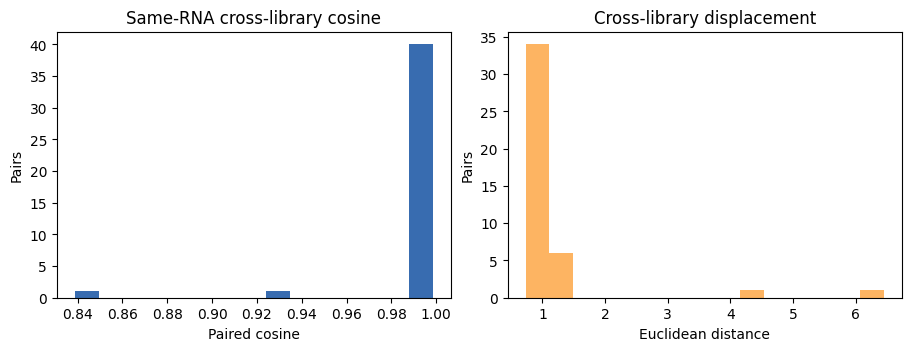

In [3]:
baseline = read_json(RESULTS/'task4c_bridge_baseline/summary.json')
display(pd.DataFrame([baseline]).style.format(precision=4))
pairs = read_csv(RESULTS/'task4c_bridge_baseline/bridge_pair_metrics.csv')
if len(pairs):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), layout='constrained')
    ax[0].hist(pairs.paired_cosine, bins=15, color='#386cb0')
    ax[0].set(xlabel='Paired cosine', ylabel='Pairs', title='Same-RNA cross-library cosine')
    ax[1].hist(pairs.euclidean_distance, bins=15, color='#fdb462')
    ax[1].set(xlabel='Euclidean distance', ylabel='Pairs', title='Cross-library displacement')
    plt.show()

High pair cosine does not guarantee donor retrieval. A dominant PolyA→Ribo difference component is evidence of reproducible displacement within a study, not proof of a universal causal library effect.

## 3. FE/RE decomposition and controls

,representation,auroc,balanced_accuracy,macro_f1,pairs,pair_cosine,pair_r1,pair_r5,pair_r10,pair_mrr,median_rank,biology_metric,biology_metric_value
0,Bridge,0.000,0.250,0.200,2,0.882,0.750,1.000,1.000,0.875,1.000,cross_library_source_identity_mrr,0.875
1,Linear baseline,0.500,0.500,0.333,2,0.883,0.750,1.000,1.000,0.875,1.000,cross_library_source_identity_mrr,0.875
2,FE,0.000,0.500,0.333,2,0.786,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
3,RE,0.000,0.250,0.200,2,0.165,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
4,FE without_pair,0.000,0.500,0.333,2,0.838,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
5,FE without_adversarial,0.078,0.250,0.200,2,0.996,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
6,FE shuffled_labels,0.000,0.000,0.000,2,1.000,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
7,FE shuffled_pairs,0.000,0.500,0.333,2,0.986,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750


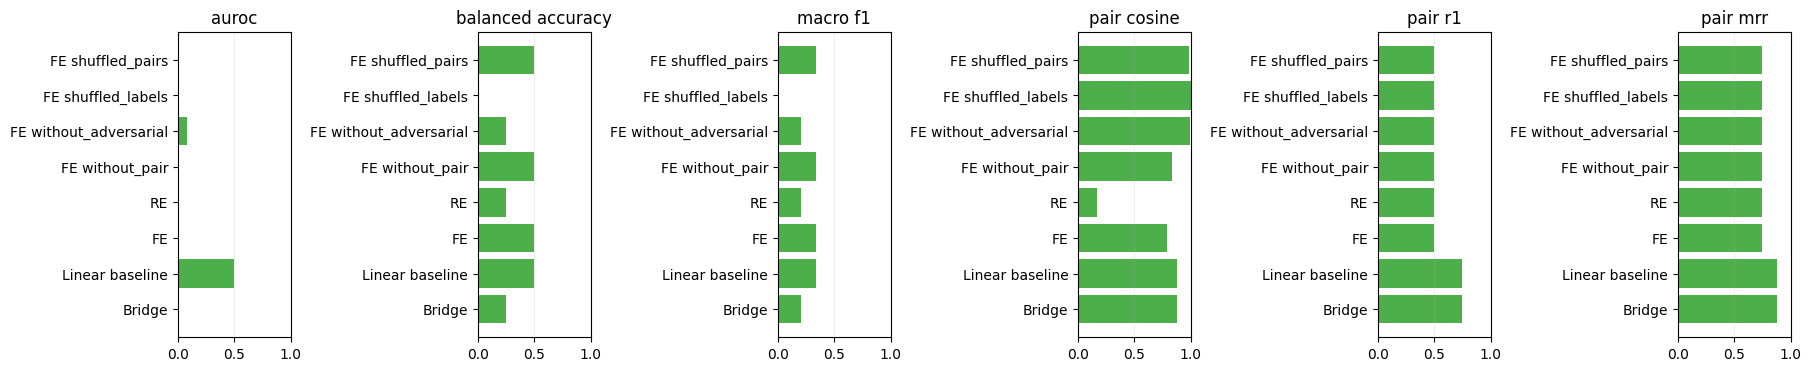

In [4]:
summary = read_csv(RESULTS/'task4_disentanglement/main_summary.csv')
if summary.empty:
    display(Markdown('*Disentanglement results are not available yet.*'))
else:
    display(summary.style.format(precision=3, na_rep='—'))
    metrics = [c for c in ['auroc','balanced_accuracy','macro_f1','pair_cosine','pair_r1','pair_mrr'] if c in summary]
    fig, axes = plt.subplots(1, len(metrics), figsize=(3*len(metrics), 3.6), layout='constrained')
    for ax, column in zip(np.atleast_1d(axes), metrics):
        ax.barh(summary.representation, summary[column], color='#4daf4a')
        ax.set(title=column.replace('_',' '), xlim=(0,1)); ax.grid(axis='x', alpha=.2)
    plt.show()

FE is successful only if held-out library prediction falls while cross-library biological identity improves. RE should retain library-associated information. Linear removal, loss ablations, and shuffled controls test whether the neural decomposition adds value.

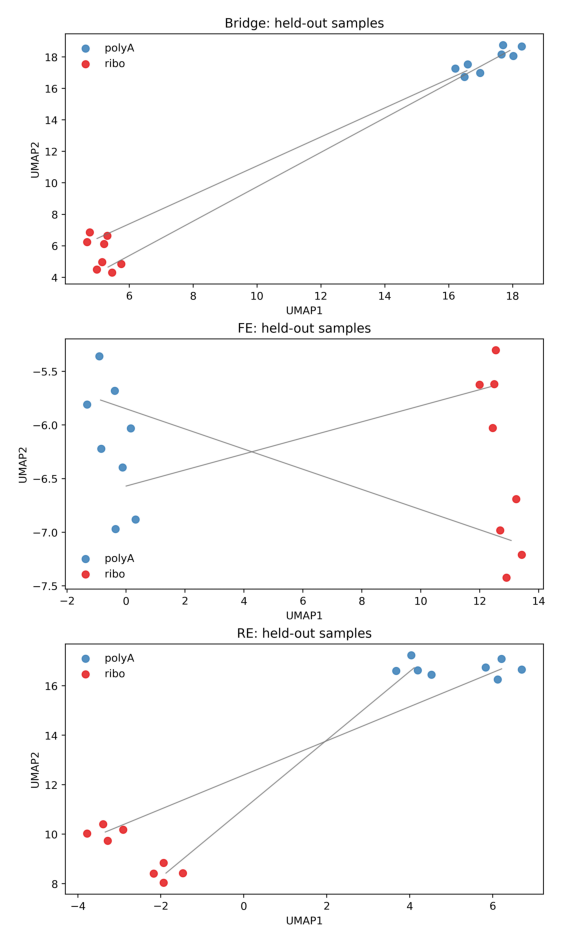

In [5]:
umap_png = RESULTS/'task4_disentanglement/heldout_representation_umaps.png'
if umap_png.exists():
    image = plt.imread(umap_png)
    plt.figure(figsize=(8,12)); plt.imshow(image); plt.axis('off'); plt.show()

## 4. Independent Task 3 challenge

,representation,comparison,left,right,cosine,spearman,left_norm,right_norm
0,Bridge,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,-0.804,-0.170,0.932,0.485
1,Bridge,RR1 ERCC,RR1_OSD48_original_matched,RR1_OSD168_all_ERCC,-0.808,-0.163,0.932,0.507
2,Bridge,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.790,0.509,0.235,0.191
3,Bridge,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.917,0.878,0.149,0.179
4,Bridge,ERCC/no-ERCC,RR1_OSD168_no-ERCC,RR1_OSD168_all_ERCC,0.998,0.993,0.485,0.507
5,Linear baseline,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,-0.709,-0.591,0.607,0.404
6,Linear baseline,RR1 ERCC,RR1_OSD48_original_matched,RR1_OSD168_all_ERCC,-0.708,-0.586,0.607,0.419
7,Linear baseline,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.724,0.637,0.193,0.170
8,Linear baseline,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.881,0.866,0.124,0.136
9,Linear baseline,ERCC/no-ERCC,RR1_OSD168_no-ERCC,RR1_OSD168_all_ERCC,0.997,0.996,0.404,0.419


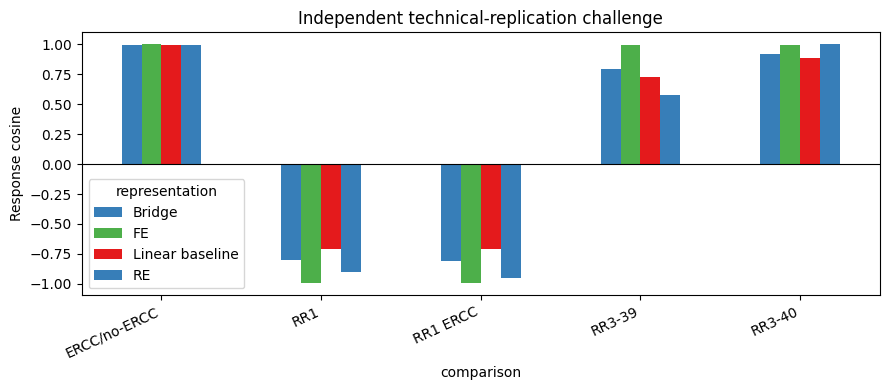

In [6]:
task3 = read_csv(RESULTS/'task4g_task3_challenge/task3_challenge_metrics.csv')
if task3.empty:
    display(Markdown('*Independent Task 3 application is not available yet.*'))
else:
    display(task3.style.format(precision=3))
    pivot = task3.pivot(index='comparison', columns='representation', values='cosine')
    ax = pivot.plot.bar(figsize=(9,4), color=['#377eb8','#4daf4a','#e41a1c'])
    ax.axhline(0,color='black',lw=.8); ax.set(ylabel='Response cosine', title='Independent technical-replication challenge')
    plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

Task 3 is an external challenge, not a tuning set. RR1 improvement matters only if RR3 and ERCC/no-ERCC relationships remain robust; changing the RR1 sign alone is not success.

## 5. Does RR1 align with a controlled PolyA→Ribo subspace?

This diagnostic uses only the **original frozen BridgeRNA embeddings**. The technical direction and SVD basis are learned from 40 verified same-RNA T-cell pairs; OSDR is used only afterward as an external diagnostic. Difference vectors are consistently defined as `Ribo − PolyA` or `OSD-168 new/Ribo-like − OSD-48 old/PolyA-like`.

The removal basis is the uncentered SVD of donor-wise differences, which retains their shared mean displacement. Centered PCA variance is also saved. This is a mechanism check—not a recommended correction.

,metric,result
0,Median controlled PolyA/Ribo pair cosine,0.9976
1,Median cosine among d_i,0.9802
2,Mean LOO technical-direction cosine,0.9860
3,LOO mismatched-null empirical p,0.0010
4,Uncentered PC1 variance explained,0.9747
5,Uncentered PC1-5 cumulative variance,0.9952
6,Independent blood alignment,-0.6572
7,Independent colon alignment,-0.7612
8,RR1 sample displacement median cosine with d_library,0.7885
9,RR1 sample displacement median variance captured PC1,0.6410


,metric,n,mean,median,sd,q25,q75,iqr
0,difference_norm,40,0.9644,0.9200,0.1698,0.8386,1.0597,0.2211
1,paired_embedding_cosine,40,0.9975,0.9976,0.0007,0.9971,0.9980,0.0009
2,pairwise_difference_cosine,780,0.9732,0.9802,0.0224,0.9675,0.9876,0.0200
3,loo_direction_cosine,40,0.9860,0.9895,0.0130,0.9860,0.9935,0.0075
4,loo_ribo_minus_polyA_projection,40,0.9512,0.9151,0.1678,0.8285,1.0516,0.2231


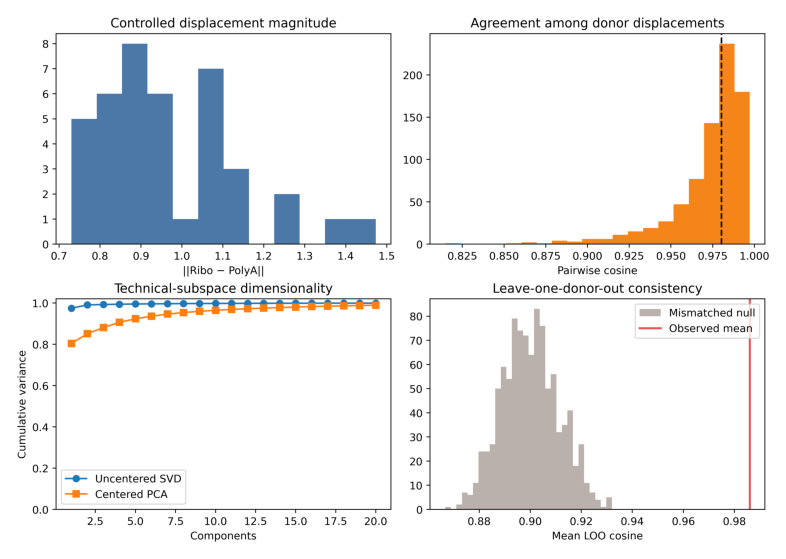

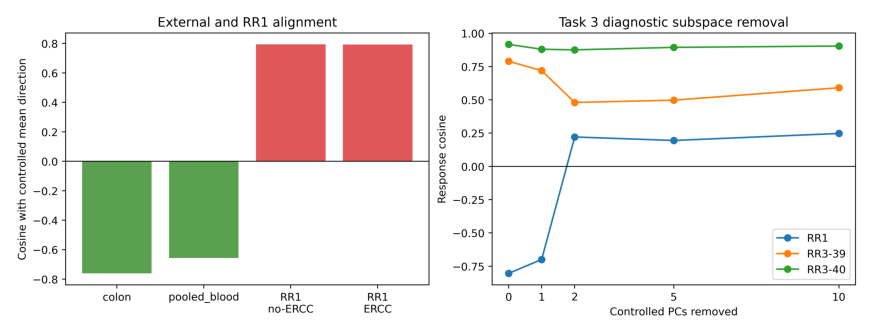

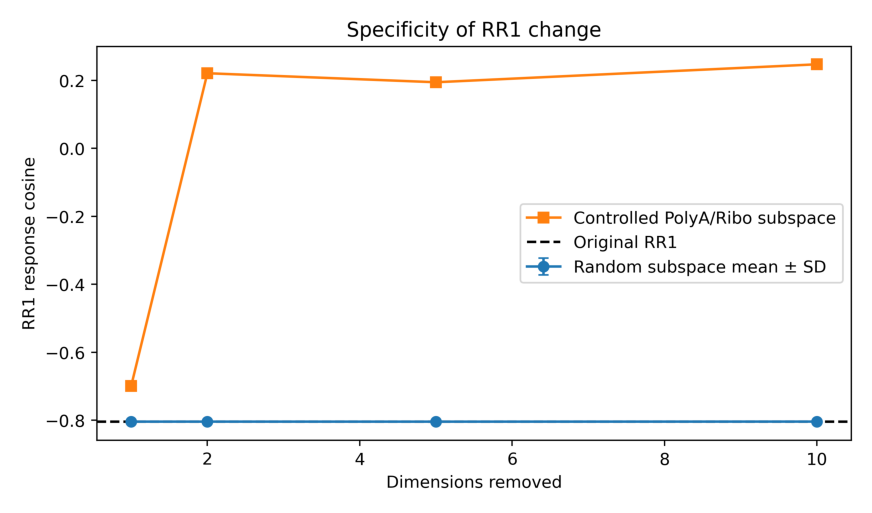

In [7]:
follow = RESULTS/'task4_followup_controlled_subspace'
diagnostic = read_csv(follow/'concise_summary.csv')
display(diagnostic.style.format({'result':'{:.4f}'}))
dist = read_csv(follow/'controlled_distribution_summary.csv')
display(dist.style.format(precision=4))
for name in ['controlled_library_geometry.png','external_rr1_alignment_and_removal.png','random_subspace_control.png']:
    path = follow/name
    if path.exists():
        img = plt.imread(path); plt.figure(figsize=(11,7)); plt.imshow(img); plt.axis('off'); plt.show()

### External orientation, correction specificity, and biological damage

An RR1 sign change is not sufficient evidence. We compare learned removal with 500 deterministic random subspaces per dimension and quantify how much original geometry, neighborhood structure, controlled pair retrieval, and RR3 technical preservation remain.

In [8]:
display(read_csv(follow/'independent_source_alignment.csv').style.format(precision=4))
display(read_csv(follow/'task3_response_after_subspace_removal.csv').style.format(precision=4))
display(read_csv(follow/'controlled_geometry_damage.csv').style.format(precision=4))
display(read_csv(follow/'random_subspace_rr1_summary.csv').style.format(precision=4))

,source,difference_norm,cosine_with_tcell_mean,fraction_magnitude_squared_in_pc1_1,fraction_magnitude_squared_in_pc1_2,fraction_magnitude_squared_in_pc1_5,fraction_magnitude_squared_in_pc1_10
0,colon,4.2291,-0.7612,0.5993,0.9689,0.9714,0.9796
1,pooled_blood,6.4471,-0.6572,0.4484,0.7842,0.8533,0.9172


,comparison,removed_components,cosine,spearman,norm_a,norm_b
0,RR1,0,-0.8041,-0.1702,0.9317,0.4853
1,RR1_ERCC,0,-0.8084,-0.1626,0.9317,0.5069
2,RR3-39,0,0.7900,0.5087,0.2347,0.1913
3,RR3-40,0,0.9166,0.8783,0.1486,0.1790
4,ERCC/no-ERCC,0,0.9981,0.9928,0.4853,0.5069
5,RR1,1,-0.6994,-0.5881,0.5935,0.3997
6,RR1_ERCC,1,-0.6985,-0.5822,0.5935,0.4139
7,RR3-39,1,0.7194,0.6354,0.1907,0.1688
8,RR3-40,1,0.8801,0.8657,0.1235,0.1347
9,ERCC/no-ERCC,1,0.9972,0.9961,0.3997,0.4139


,removed_components,mean_original_corrected_cosine,median_original_corrected_cosine,mean_top10_neighbor_overlap,variance_removed_fraction,median_pair_cosine,pair_r1,pair_r5,pair_r10,pair_mrr,median_rank
0,1,0.7743,0.7700,0.4700,0.4021,0.9999,0.8500,0.9250,0.9500,0.8878,1.0000
1,2,0.6724,0.6700,0.3212,0.5493,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000
2,5,0.6604,0.6589,0.3137,0.5653,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,10,0.6309,0.6311,0.3137,0.6033,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,removed_components,mean,median,std,min,max,learned_rr1_cosine,fraction_random_at_least_as_improved
0,1,-0.8041,-0.8041,0.0007,-0.8082,-0.8011,-0.6994,0.0000
1,2,-0.8041,-0.8042,0.0009,-0.8074,-0.7995,0.2210,0.0000
2,5,-0.8042,-0.8042,0.0016,-0.8086,-0.7984,0.1945,0.0000
3,10,-0.8040,-0.8040,0.0022,-0.8106,-0.7954,0.2473,0.0000


The controlled T-cell effect is strongly reproducible *within that study*, and individual RR1 old→new displacements substantially project into the T-cell basis. However, held-out pooled blood and colon point in the opposite orientation. Five-component removal changes RR1 strongly and much more than random removal, but also removes a large fraction of embedding energy, disrupts neighborhoods, and weakens RR3-39. Therefore this supports **partial, context-dependent overlap**, not a universal PolyA/Ribo direction or a validated correction. The next correction effort should model the broader protocol transition and acquire additional independent same-RNA studies rather than treating library selection alone as established causality.

## 6. Held-out response-geometry robustness

The following analysis removes the independently learned T-cell technical basis from **individual OSDR sample embeddings before** reconstructing each fixed `FLT − GC` response. No OSDR result affects the basis. Original sample memberships, technical-replication mappings, 14 response vectors, ordering, and mode labels are unchanged.

The primary preservation evidence is response-level—not global sample neighborhoods. Results are shown for 0, 1, 2, 3, 5, and 10 removed dimensions, with 500 deterministic random orthonormal controls per nonzero dimension.

,comparison,recomputed_cosine,saved_cosine,absolute_difference,verified
0,RR1 noERCC,-0.804119,-0.804119,0.000000,True
1,RR1 allERCC,-0.808434,-0.808434,0.000000,True
2,RR3-39,0.790004,0.790003,0.000000,True
3,RR3-40,0.916648,0.916649,0.000000,True


,comparison,0,1,2,3,5,10
0,OSD168 noERCC/allERCC,0.998,0.997,0.991,0.992,0.992,0.992
1,RR1 allERCC,-0.808,-0.699,0.241,0.212,0.204,0.249
2,RR1 noERCC,-0.804,-0.699,0.221,0.198,0.195,0.247
3,RR3-39,0.790,0.719,0.480,0.509,0.497,0.591
4,RR3-40,0.917,0.880,0.876,0.879,0.894,0.904


,comparison,0,1,2,3,5,10
0,OSD168 noERCC/allERCC,0.993,0.996,0.991,0.991,0.991,0.991
1,RR1 allERCC,-0.163,-0.582,0.226,0.188,0.186,0.235
2,RR1 noERCC,-0.170,-0.588,0.203,0.173,0.173,0.232
3,RR3-39,0.509,0.635,0.447,0.483,0.476,0.574
4,RR3-40,0.878,0.866,0.869,0.871,0.889,0.900


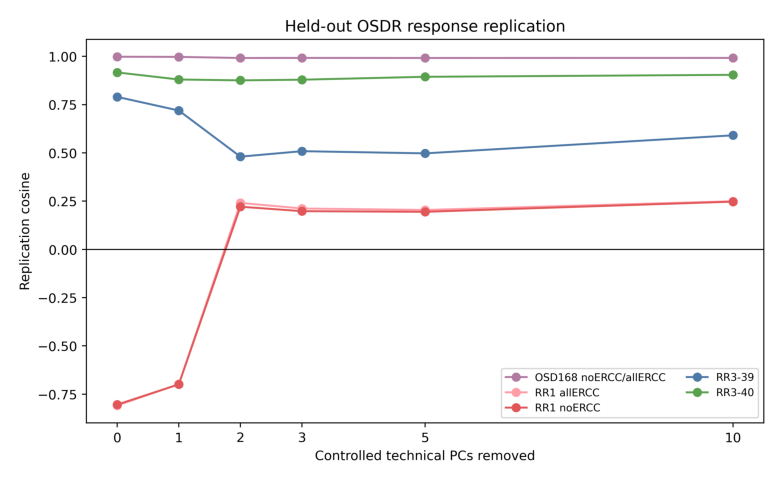

In [9]:
robust = RESULTS/'task4_response_robustness'
verify = read_csv(robust/'original_metric_verification.csv')
display(verify.style.format(precision=6))
display(read_csv(robust/'technical_replication_cosine_curve.csv').style.format(precision=3))
display(read_csv(robust/'technical_replication_spearman_curve.csv').style.format(precision=3))
img=plt.imread(robust/'figure_a_replication_curve.png');plt.figure(figsize=(11,6));plt.imshow(img);plt.axis('off');plt.show()

### Response damage and fixed-mode preservation

For an orthogonal projection, `cos(Δz_original, Δz_corrected)` equals the retained norm fraction; both are retained in the raw table for clarity. Mode assignments are never refit. ARI compares unsupervised two-cluster structure with the original fixed labels.

,removed_components,contrast_group,contrasts,response_cosine_mean,response_cosine_median,response_cosine_sd,norm_ratio_mean,norm_ratio_median,norm_ratio_sd
0,0,RR1,3,1.000,1.000,0.000,1.000,1.000,0.000
1,0,RR3,5,1.000,1.000,0.000,1.000,1.000,0.000
2,0,other,6,1.000,1.000,0.000,1.000,1.000,0.000
3,1,RR1,3,0.756,0.764,0.108,0.756,0.764,0.108
4,1,RR3,5,0.812,0.813,0.061,0.812,0.813,0.061
5,1,other,6,0.829,0.796,0.127,0.829,0.796,0.127
6,2,RR1,3,0.416,0.337,0.217,0.416,0.337,0.217
7,2,RR3,5,0.566,0.557,0.064,0.566,0.557,0.064
8,2,other,6,0.638,0.577,0.251,0.638,0.577,0.251
9,3,RR1,3,0.414,0.335,0.218,0.414,0.335,0.218


,removed_components,same_mode_mean,same_mode_median,different_mode_mean,different_mode_median,same_minus_different_mean,silhouette_cosine_fixed_labels,cluster_ARI_vs_original_labels,matrix_spearman_vs_original,matrix_pearson_vs_original
0,0,0.638,0.737,-0.624,-0.705,1.261,0.763,1.000,1.000,1.000
1,1,0.525,0.604,-0.509,-0.572,1.034,0.666,1.000,0.988,0.989
2,2,0.141,0.171,-0.139,-0.148,0.280,0.225,0.272,0.619,0.560
3,3,0.149,0.163,-0.142,-0.161,0.290,0.233,0.272,0.611,0.562
4,5,0.128,0.111,-0.119,-0.131,0.247,0.200,0.116,0.559,0.511
5,10,0.130,0.058,-0.124,-0.137,0.255,0.204,0.116,0.576,0.527


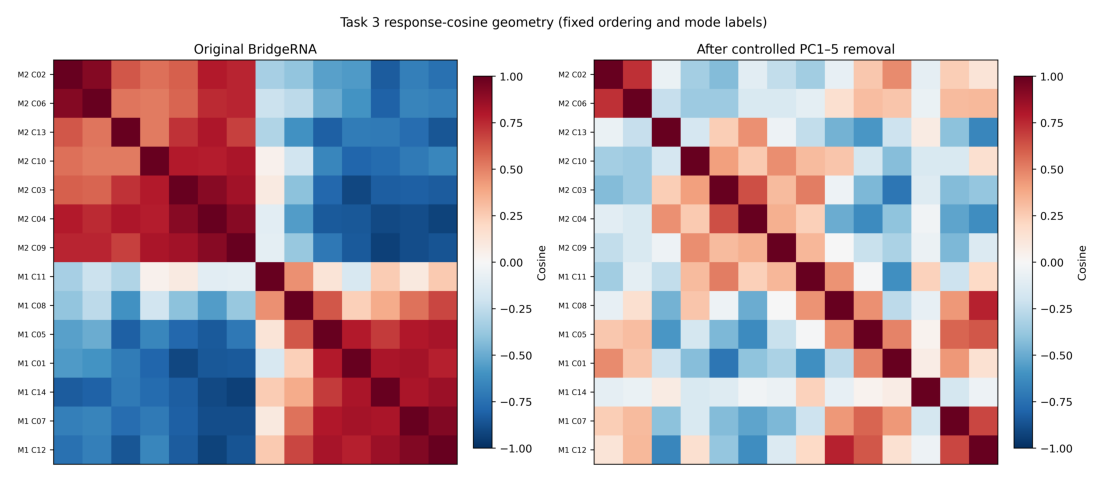

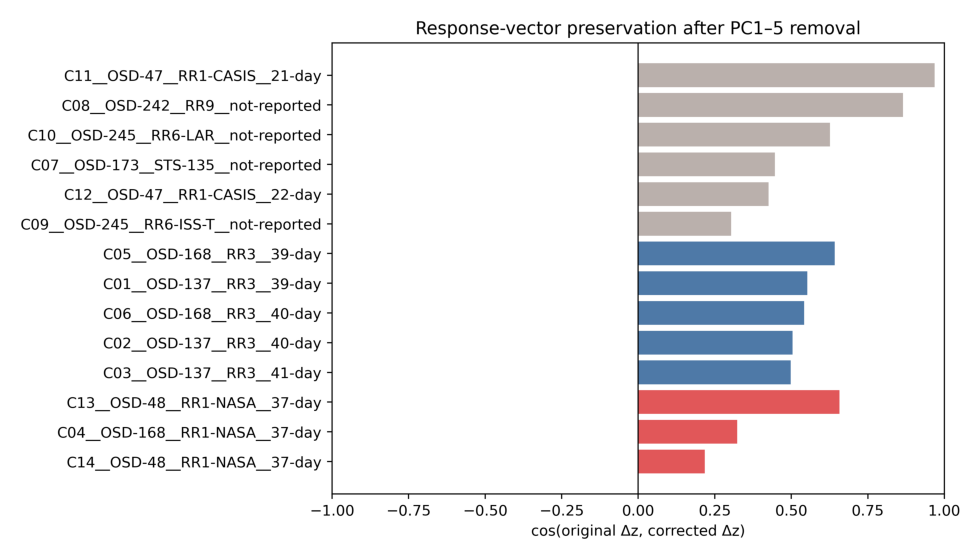

In [10]:
display(read_csv(robust/'response_damage_summary.csv').style.format(precision=3))
display(read_csv(robust/'task3_mode_preservation.csv').style.format(precision=3))
for name in ['figure_b_response_matrices.png','figure_c_response_preservation.png']:
    img=plt.imread(robust/name);plt.figure(figsize=(14,7));plt.imshow(img);plt.axis('off');plt.show()

### Selectivity and absolute-space versus response-space geometry

The controlled basis is compared with at least 500 random bases at every dimension. A selective RR1 change is informative mechanistically, but it is not sufficient if RR3 or the broader response organization is damaged.

,removed_components,metric,controlled_value,random_mean,random_sd,empirical_percentile,one_sided_p_random_at_least_as_high
0,1,rr1_cosine,-0.6994,-0.8041,0.0007,1.0000,0.0020
1,1,rr3_39_cosine,0.7194,0.7900,0.0007,0.0000,1.0000
2,1,rr3_40_cosine,0.8801,0.9166,0.0003,0.0000,1.0000
3,1,same_minus_different_mean,1.0338,1.2615,0.0011,0.0000,1.0000
4,1,matrix_spearman_vs_original,0.9881,1.0000,0.0000,0.0000,1.0000
5,2,rr1_cosine,0.2210,-0.8041,0.0010,1.0000,0.0020
6,2,rr3_39_cosine,0.4804,0.7900,0.0010,0.0000,1.0000
7,2,rr3_40_cosine,0.8756,0.9167,0.0004,0.0000,1.0000
8,2,same_minus_different_mean,0.2797,1.2615,0.0017,0.0000,1.0000
9,2,matrix_spearman_vs_original,0.6188,1.0000,0.0000,0.0000,1.0000


,metric,result
0,RR1 cosine original,-0.8041
1,RR1 cosine PC1-5 removed,0.1945
2,RR3-39 cosine original,0.7900
3,RR3-39 cosine PC1-5 removed,0.4974
4,RR3-40 cosine original,0.9166
5,RR3-40 cosine PC1-5 removed,0.8941
6,Median response-vector preservation PC1-5,0.5232
7,Median response norm ratio PC1-5,0.5232
8,Response-matrix Spearman preservation PC1-5,0.5592
9,Mode silhouette original,0.7630


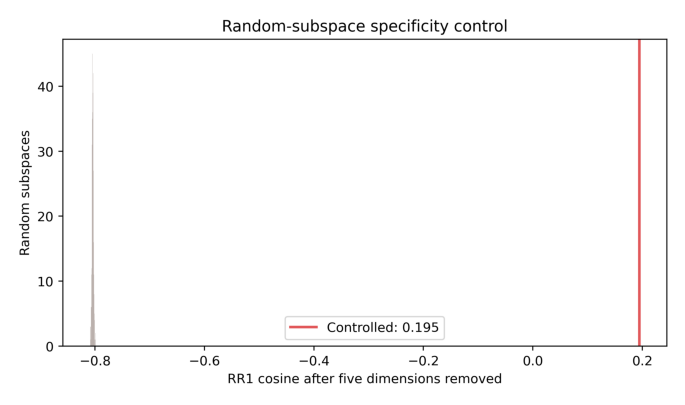

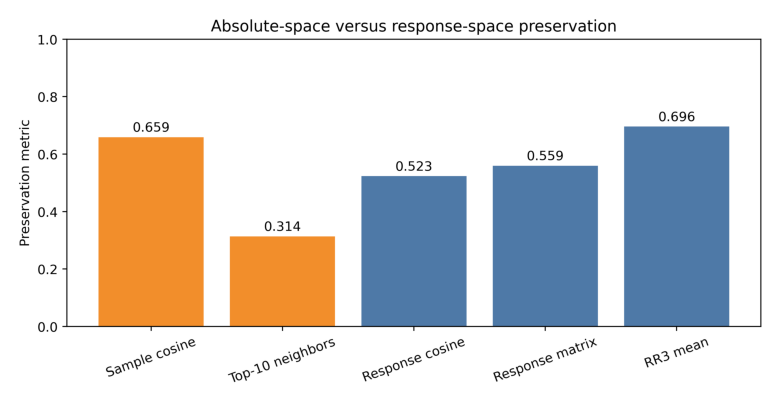

In [11]:
display(read_csv(robust/'random_subspace_summary.csv').style.format(precision=4))
display(read_csv(robust/'concise_summary.csv').style.format({'result':'{:.4f}'}))
for name in ['figure_d_rr1_random_null.png','figure_e_absolute_vs_response.png']:
    img=plt.imread(robust/name);plt.figure(figsize=(10,5));plt.imshow(img);plt.axis('off');plt.show()

### Response-robustness conclusion

1. **RR1:** The independently learned basis explains a specific component of the RR1 reversal: PC1–5 removal changes cosine from about −0.804 to +0.195, beyond all 500 matched random removals.
2. **RR3:** Preservation is mixed. RR3-40 remains high, whereas RR3-39 falls materially.
3. **Broader Task 3 geometry:** It is not preserved well after five components. The response-matrix correlation falls to roughly 0.56, fixed-label silhouette drops sharply, and unsupervised agreement with the original modes is low.
4. **Response versus absolute geometry:** Median response preservation is somewhat lower than median absolute sample cosine, though it exceeds Top-10 neighborhood overlap. These results do not show that response geometry is generally immune to the removal.
5. **Usefulness of Δz:** Uncorrected within-study response vectors remain valuable for controlled cross-study technical comparisons, but this particular removal trades a selective RR1 improvement against substantial global response reorganization.
6. **Purified biology:** **No.** We have identified and removed a controlled, technical-associated subspace; neither the residual nor its positive RR1 cosine can be called pure spaceflight biology.

## 7. Gene-level basis of RR1 instability

Signed Integrated Gradients are computed independently for the six fixed response measurements using the established zero-expression baseline and frozen BridgeRNA encoder. Within each technical pair, the **original OSD-48 or OSD-137 Δz direction is held fixed** for both measurements. This is essential: orienting each response toward itself would conceal reversal. The controlled signature is independently defined as `IG(mean T-cell Ribo) − IG(mean T-cell PolyA)` along the controlled mean latent displacement.

Genes are ranked by absolute attribution while retaining sign. The tables below verify the latent responses and compare Top-100 overlap, random-overlap enrichment, genome-wide signed Spearman correlation, union-Top-100 correlation, and sign agreement.

,comparison,original_response,remeasurement_response,original_norm,remeasurement_norm,recomputed_cosine,saved_cosine,absolute_difference,verified
0,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,0.931650,0.485264,-0.804119,-0.804119,0.000000,True
1,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.234695,0.191301,0.790003,0.790003,0.000000,True
2,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.148579,0.178983,0.916649,0.916649,0.000000,True


,top_n,shared,jaccard,expected_random_overlap,overlap_enrichment,hypergeom_p,same_sign_fraction,opposite_sign_fraction,comparison,full_signed_spearman,top100_union_signed_spearman
0,100,53,0.3605,0.6594,80.3745,0.0000,0.9623,0.0377,RR1,0.1938,0.6547
1,100,71,0.5504,0.6594,107.6715,0.0000,0.9859,0.0141,RR3-39,0.6012,0.8297
2,100,76,0.6129,0.6594,115.2540,0.0000,1.0000,0.0000,RR3-40,0.5972,0.8736


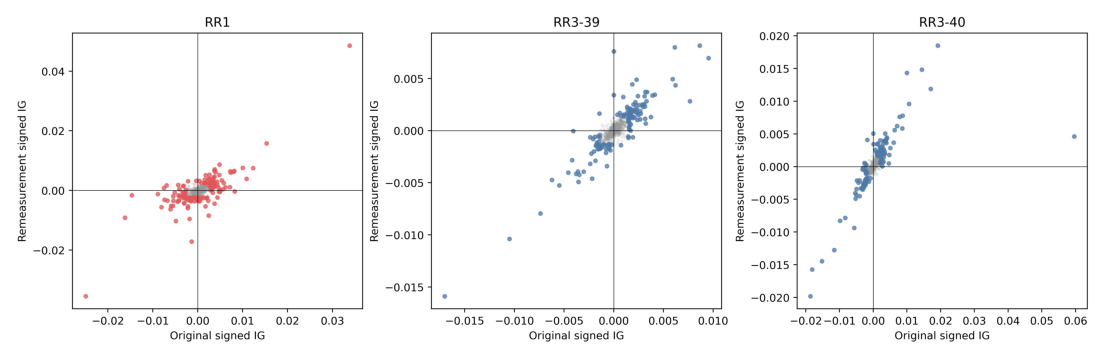

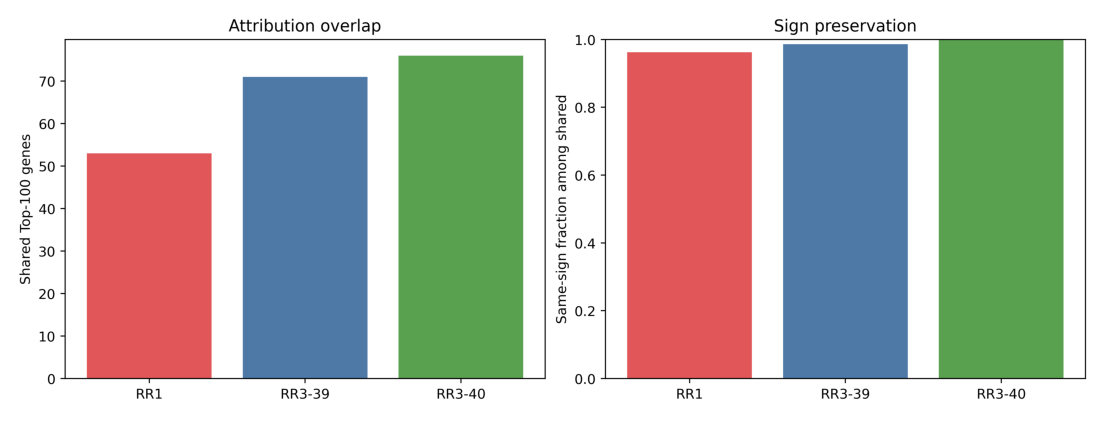

In [12]:
gene_diag=RESULTS/'task4_gene_attribution_diagnostic'
display(read_csv(gene_diag/'latent_response_verification.csv').style.format(precision=6))
ig_compare=read_csv(gene_diag/'technical_replication_ig_comparison.csv')
display(ig_compare.style.format(precision=4))
for name in ['figure_a_signed_attribution_scatter.png','figure_b_top100_overlap_sign.png']:
    img=plt.imread(gene_diag/name);plt.figure(figsize=(14,6));plt.imshow(img);plt.axis('off');plt.show()

### Controlled technical signature and expression-level control

The controlled PolyA→Ribo signature is compared with `remeasurement attribution − original attribution` at Top-100, Top-250, and Top-500. These cutoff analyses are sensitivity checks, not independent tests. Conventional expression uses the identical samples and 15,165-gene `log1p(TPM)` inputs.

,top_n,shared,jaccard,expected_random_overlap,overlap_enrichment,hypergeom_p,same_sign_fraction,opposite_sign_fraction,comparison,signature
0,100,11,0.0582,0.6594,16.6815,0.0000,0.4545,0.5455,RR1,controlled_vs_remeasurement_minus_original
1,250,49,0.1086,4.1213,11.8894,0.0000,0.4490,0.5510,RR1,controlled_vs_remeasurement_minus_original
2,500,125,0.1429,16.4853,7.5825,0.0000,0.4560,0.5440,RR1,controlled_vs_remeasurement_minus_original
3,100,10,0.0526,0.6594,15.1650,0.0000,0.5000,0.5000,RR3-39,controlled_vs_remeasurement_minus_original
4,250,37,0.0799,4.1213,8.9777,0.0000,0.5676,0.4324,RR3-39,controlled_vs_remeasurement_minus_original
5,500,94,0.1038,16.4853,5.7020,0.0000,0.5851,0.4149,RR3-39,controlled_vs_remeasurement_minus_original
6,100,9,0.0471,0.6594,13.6485,0.0000,0.5556,0.4444,RR3-40,controlled_vs_remeasurement_minus_original
7,250,39,0.0846,4.1213,9.4630,0.0000,0.4359,0.5641,RR3-40,controlled_vs_remeasurement_minus_original
8,500,100,0.1111,16.4853,6.0660,0.0000,0.5100,0.4900,RR3-40,controlled_vs_remeasurement_minus_original


,top_n,shared,jaccard,expected_random_overlap,overlap_enrichment,hypergeom_p,same_sign_fraction,opposite_sign_fraction,comparison,full_gene_cosine,full_gene_spearman
0,100,46,0.2987,0.6594,69.7590,0.0000,1.0000,0.0000,RR1,0.3692,0.4248
1,100,58,0.4085,0.6594,87.9570,0.0000,1.0000,0.0000,RR3-39,0.6523,0.6183
2,100,87,0.7699,0.6594,131.9355,0.0000,1.0000,0.0000,RR3-40,0.8224,0.6730


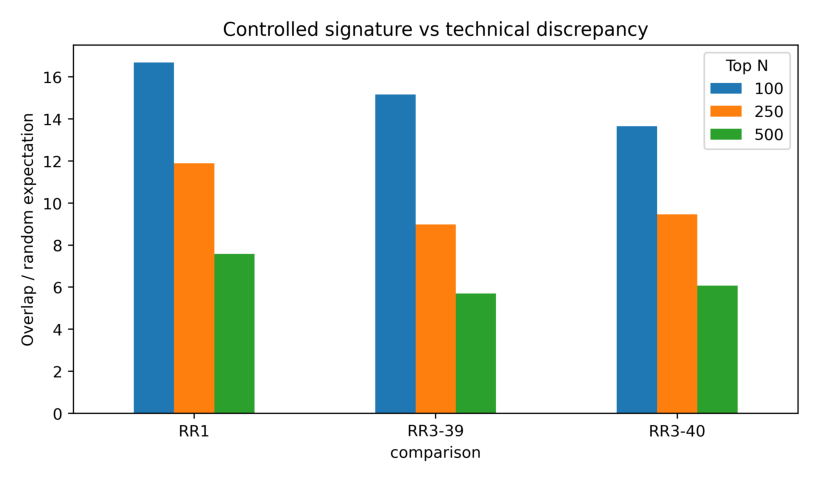

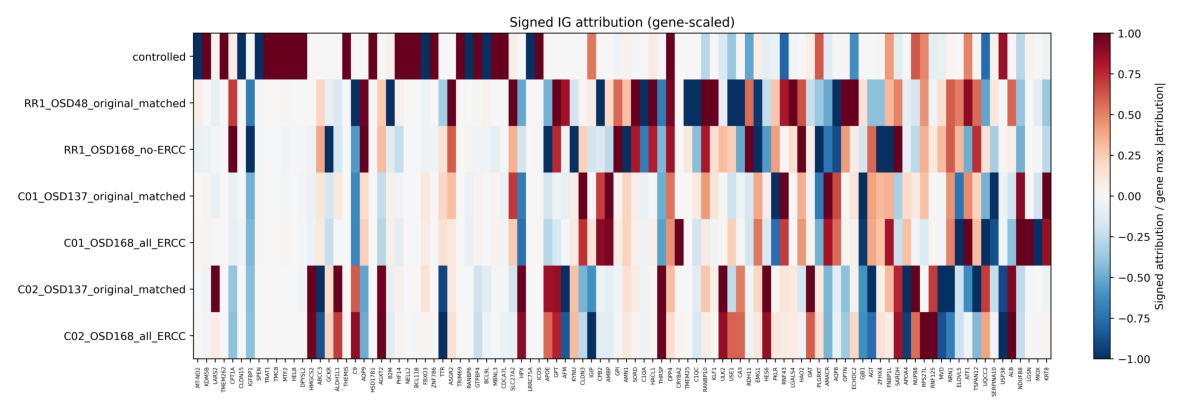

In [13]:
display(read_csv(gene_diag/'controlled_signature_discrepancy_overlap.csv').style.format(precision=4))
display(read_csv(gene_diag/'expression_response_comparison.csv').style.format(precision=4))
for name in ['figure_c_controlled_signature_overlap.png','figure_d_signed_gene_heatmap.png']:
    img=plt.imread(gene_diag/name);plt.figure(figsize=(15,6));plt.imshow(img);plt.axis('off');plt.show()

### Gene-set interpretation

GO Biological Process, KEGG, and Reactome enrichment uses the exact 15,165-gene model vocabulary as custom background with g:Profiler multiple-testing correction. Empty gene-set/source combinations mean no significant terms, not missing computation. Attribution is associative and is not evidence that a gene causes technical sensitivity.

In [14]:
enrichment=read_csv(gene_diag/'enrichment.csv')
if len(enrichment):
    cols=[c for c in ['query','source','native','name','p_value','intersection_size'] if c in enrichment]
    display(enrichment.sort_values('p_value').groupby('query',group_keys=False).head(12)[cols].style.format({'p_value':'{:.2e}'}))
display(read_csv(gene_diag/'interpretation_gene_sets.csv').groupby('gene_set').size().rename('genes').to_frame())

,query,source,native,name,p_value,intersection_size
0,RR3_reproducible,REAC,REAC:R-HSA-1430728,Metabolism,9.23e-12,48
1,RR3_reproducible,GO:BP,GO:0044281,small molecule metabolic process,5.17e-10,43
2,RR3_reproducible,GO:BP,GO:0043436,oxoacid metabolic process,9.55e-09,30
3,RR3_reproducible,GO:BP,GO:0006082,organic acid metabolic process,1.21e-08,30
4,RR3_reproducible,GO:BP,GO:0019752,carboxylic acid metabolic process,3.36e-08,29
5,RR1_shared_same_sign,GO:BP,GO:0044282,small molecule catabolic process,8.33e-07,13
6,RR1_shared_same_sign,GO:BP,GO:0044281,small molecule metabolic process,2.45e-06,23
7,RR1_shared_same_sign,KEGG,KEGG:01200,Carbon metabolism,3.41e-06,7
8,RR1_shared_same_sign,KEGG,KEGG:04976,Bile secretion,4.81e-06,6
9,RR1_shared_same_sign,REAC,REAC:R-HSA-1430728,Metabolism,1.19e-05,22


,genes
gene_set,
RR1_original_specific,47
RR1_remeasurement_specific,47
RR1_shared_opposite_sign,2
RR1_shared_same_sign,51
RR3_reproducible,123
controlled_and_RR1_discrepancy,11
controlled_polyA_ribo_top100,100


### Gene-level conclusion

1. **RR1 is a mixture, dominated by attribution reweighting rather than simple sign reversal.** It retains 53 shared Top-100 genes, 96.2% with the same sign, but genome-wide signed Spearman is only 0.194. Its reversed latent vector therefore arises from broad changes in attribution magnitude and the remaining gene set, not wholesale reversal of the shared leading genes.
2. **RR3 is more reproducible.** RR3-39 and RR3-40 share 71 and 76 Top-100 genes, with genome-wide signed Spearman around 0.60 and nearly complete sign preservation.
3. **Controlled-signature overlap is statistically enriched but only modestly preferential for RR1.** RR1 shares 11/49/125 genes at Top-100/250/500 versus 10/37/94 for RR3-39 and 9/39/100 for RR3-40. This supports partial overlap, not a uniquely PolyA/Ribo-driven RR1 mechanism.
4. **Expression already contains the instability.** RR1 expression cosine is 0.369, below RR3-39 (0.652) and RR3-40 (0.822). BridgeRNA reorganizes and accentuates an existing expression-level discrepancy.
5. **Biology:** Shared RR1 genes and reproducible RR3 genes both emphasize hepatic small-molecule, organic-acid, lipid, bile-secretion, and broader metabolic programs. No significant coherent enrichment was detected for the two opposite-sign RR1 genes, measurement-specific sets, controlled Top-100 signature, or the 11-gene controlled/RR1 intersection.

The technically unstable RR1 response has an interpretable gene-level signature, but these results neither identify causal “batch genes” nor isolate pure biological signal.

## 8. Are simple corrections better than controlled SVD projection?

All linear corrections are learned solely from the 40 paired T-cell donors. Controlled-pair evaluation uses leave-one-donor-out fitting and testing. OSDR remains fully held out. The comparison includes no correction, mean-direction projection, SVD PC1–1/2/3/5, paired additive residualization, and the already trained FE representation.

`library_auroc` retains the signed held-donor result. An AUROC near zero represents systematic inversion, not proof that library information vanished; `library_orientation_free_auroc` and `library_accuracy_chance_proximity` make that distinction explicit. FE Euclidean distances and original-versus-corrected vector cosines are not comparable across its 64-D coordinate system and the original 512-D space.

In [15]:
simple=RESULTS/'task4_simple_correction_comparison'
trade=read_csv(simple/'correction_tradeoff_summary.csv')
show=['method','paired_cosine','paired_euclidean','pair_r1','library_auroc','library_orientation_free_auroc','library_accuracy_chance_proximity','RR1','RR3-39','RR3-40','response_matrix_preservation','median_response_preservation','mode_ARI','mode_silhouette','sample_cosine_preservation','top10_neighbor_overlap']
display(trade[[c for c in show if c in trade]].style.format(precision=3,na_rep='—'))
display(read_csv(simple/'svd_correction_curve.csv').style.format(precision=3))

,method,paired_cosine,paired_euclidean,pair_r1,library_auroc,library_orientation_free_auroc,library_accuracy_chance_proximity,RR1,RR3-39,RR3-40,response_matrix_preservation,median_response_preservation,mode_ARI,mode_silhouette,sample_cosine_preservation,top10_neighbor_overlap
0,none,0.998,0.920,0.100,1.000,1.000,0.000,-0.804,0.790,0.917,1.000,1.000,1.000,0.763,1.000,1.000
1,mean_direction_projection,1.000,0.133,0.825,0.000,1.000,0.000,-0.709,0.724,0.881,0.989,0.799,1.000,0.673,0.724,0.930
2,svd_pc1_1,1.000,0.139,0.812,0.000,1.000,0.000,-0.699,0.719,0.880,0.988,0.788,1.000,0.666,0.714,0.929
3,svd_pc1_2,1.000,0.091,0.988,0.202,0.798,0.650,0.221,0.480,0.876,0.619,0.541,0.272,0.225,0.555,0.758
4,svd_pc1_3,1.000,0.087,1.000,0.247,0.753,0.625,0.198,0.509,0.879,0.611,0.534,0.272,0.233,0.552,0.757
5,svd_pc1_5,1.000,0.075,1.000,0.287,0.713,0.650,0.195,0.497,0.894,0.559,0.523,0.116,0.200,0.549,0.737
6,paired_additive_residualization,1.000,0.172,0.688,0.000,1.000,0.025,-0.804,0.790,0.917,1.000,1.000,1.000,0.763,1.000,0.938
7,FE_existing,0.995,94.013,0.025,1.000,1.000,0.000,-0.994,0.998,0.995,0.885,—,1.000,0.995,—,0.445


,method,RR1,RR3-39,RR3-40,response_matrix_preservation,median_response_preservation,mode_ARI,mode_silhouette
0,none,-0.804,0.790,0.917,1.000,1.000,1.000,0.763
1,svd_pc1_1,-0.699,0.719,0.880,0.988,0.788,1.000,0.666
2,svd_pc1_2,0.221,0.480,0.876,0.619,0.541,0.272,0.225
3,svd_pc1_3,0.198,0.509,0.879,0.611,0.534,0.272,0.233
4,svd_pc1_5,0.195,0.497,0.894,0.559,0.523,0.116,0.200


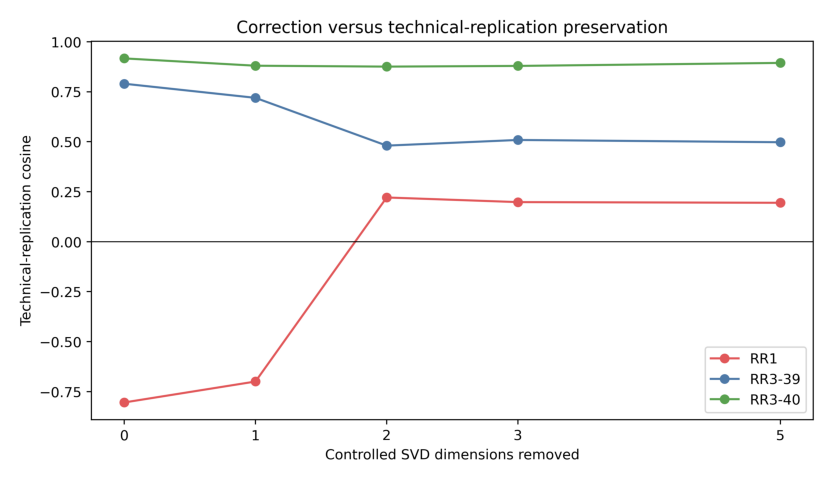

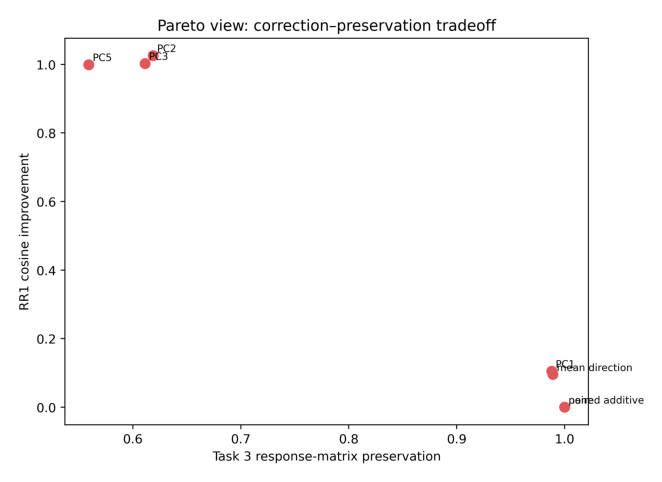

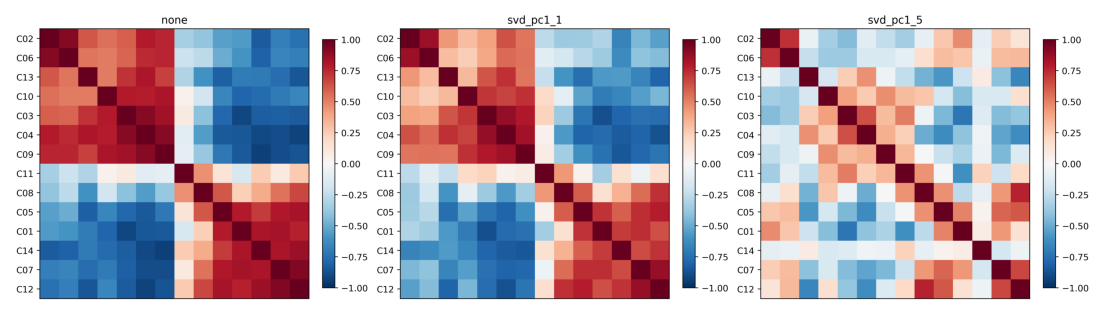

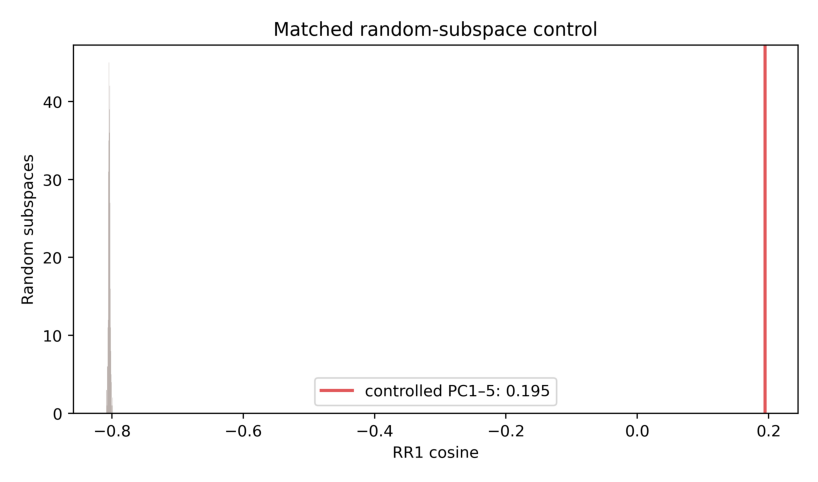

In [16]:
for name in ['figure_a_correction_curves.png','figure_b_pareto_tradeoff.png','figure_c_selected_response_matrices.png','figure_d_random_control.png']:
    img=plt.imread(simple/name);plt.figure(figsize=(14,6));plt.imshow(img);plt.axis('off');plt.show()

### Correction–preservation conclusion

1. **Was SVD projection better?** Not generally. Mean-direction projection and SVD PC1 are nearly equivalent compromises. PC2+ is uniquely capable of making RR1 positive, but only alongside substantial loss of RR3-39 and broader response organization.
2. **Controlled pair removal:** SVD PC1–5 gives the smallest paired distance and perfect donor R@1, but held-donor protocol predictions remain orientation-decodable (orientation-free AUROC 0.713). Systematic prediction inversion for several methods must not be called protocol erasure.
3. **Best preservation:** Paired additive residualization preserves RR3 and all FLT−GC response geometry exactly because its study-constant protocol offset cancels algebraically. Consequently, it leaves RR1 unchanged. Among projections, mean-direction/PC1 preserves the most structure.
4. **RR1 without substantial damage:** No evaluated method does this. PC1 improves RR1 only from −0.804 to about −0.70. PC1–2 makes RR1 positive but response-matrix preservation falls to 0.619, median response preservation to 0.541, and ARI to 0.272.
5. **PC1 versus PC1–5:** PC1 is the better preservation compromise, but it is not an RR1 solution. PC1–5 is a stronger technical perturbation with unacceptable response damage.
6. **Pareto result:** Multiple methods are non-dominated because technical removal, RR1 movement, and response preservation conflict. There is no jointly successful operating point.
7. **Recommended use:** The controlled basis is most defensible for **diagnostic quantification**, not routine correction. It identifies RR1-sensitive directions, but current evidence does not demonstrate separability of technical and biological response components.

The residual spaces are not purified biology, and none of these results imply that BridgeRNA removes batch effects.

## 9. Diagnostic decomposition of technical-replication discrepancies

This analysis does **not** correct or remove dimensions from any embedding. For each NASA technical replication it defines $\delta=\Delta z_{original}-\Delta z_{remeasurement}$ and measures how much of that discrepancy lies in the uncentered SVD basis fitted only to 40 independent same-RNA T-cell Ribo-minus-PolyA displacements. Random 1/2/3/5-dimensional subspaces provide a 1,000-replicate calibration for each comparison and dimension.

`parallel` means *aligned with the independently characterized library-associated transformation*; it is not a pure technical effect. The orthogonal component is likewise not pure biology. For cross-context directional comparisons, NASA vectors are displayed in original-to-remeasurement orientation (`-delta`) to match the controlled PolyA-to-Ribo convention.

In [17]:
diag=RESULTS/'task4_discrepancy_decomposition'
compact=read_csv(diag/'rr1_rr3_compact_comparison.csv')
display(compact.style.format(precision=4))
display(read_csv(diag/'random_subspace_calibration.csv').style.format(precision=4))

,comparison,original_replication_cosine,discrepancy_norm,PC1_alignment,fraction_PC1,fraction_PC1_2,fraction_PC1_3,fraction_PC1_5,random_percentile_PC1_5,empirical_p_PC1_5
0,RR1,-0.8041,1.3530,0.7342,0.5390,0.9531,0.9533,0.9597,1.0000,0.0010
1,RR3-39,0.7900,0.1440,0.3251,0.1057,0.1410,0.2075,0.2262,1.0000,0.0010
2,RR3-40,0.9166,0.0732,0.4820,0.2323,0.4663,0.4823,0.5603,1.0000,0.0010


,comparison,components,observed_fraction,random_median,random_q025,random_q975,empirical_percentile,empirical_p_one_sided
0,RR1,1,0.5390,0.0009,0.0000,0.0111,1.0000,0.0010
1,RR1,2,0.9531,0.0028,0.0001,0.0143,1.0000,0.0010
2,RR1,3,0.9533,0.0047,0.0005,0.0178,1.0000,0.0010
3,RR1,5,0.9597,0.0086,0.0018,0.0242,1.0000,0.0010
4,RR3-39,1,0.1057,0.0009,0.0000,0.0087,1.0000,0.0010
5,RR3-39,2,0.1410,0.0028,0.0001,0.0138,1.0000,0.0010
6,RR3-39,3,0.2075,0.0049,0.0006,0.0184,1.0000,0.0010
7,RR3-39,5,0.2262,0.0083,0.0015,0.0252,1.0000,0.0010
8,RR3-40,1,0.2323,0.0010,0.0000,0.0104,1.0000,0.0010
9,RR3-40,2,0.4663,0.0029,0.0001,0.0145,1.0000,0.0010


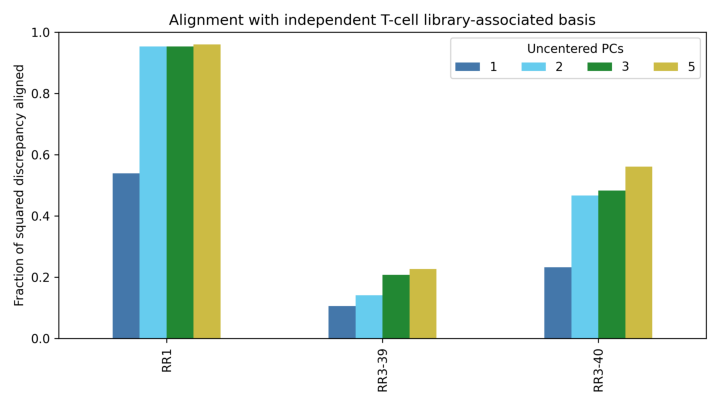

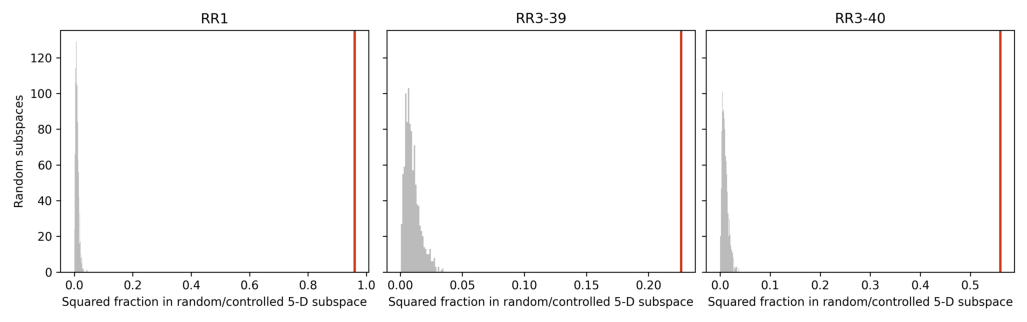

In [18]:
for name in ['discrepancy_alignment.png','random_subspace_calibration.png']:
    img=plt.imread(diag/name);plt.figure(figsize=(13,5));plt.imshow(img);plt.axis('off');plt.show()

### Additive-vector and preservation-interaction checks

The controlled donor displacements are internally coherent, but the only held-out pooled-blood and colon source vectors point in the opposite direction from the T-cell mean. Those two sources each represent only one biological source and cannot establish tissue specificity. Together with heterogeneous NASA alignment, this is inconsistent with treating one additive vector as universally transferable; a context-dependent transformation remains the more defensible working model.

The Lai Polo study explicitly reported that collection/preservation effects were exacerbated with polyA selection. Our cached OSDR design audit nevertheless does not contain the crossed, same-material combinations needed to independently estimate preservation, library selection, and their interaction. OSD-48 C13/C14 offers a preservation comparison in different animals; OSD-48 C14 to OSD-168 offers exact-material remeasurement across a broader library/sequencing transition; OSD-168 ERCC comparisons hold library and source material fixed. These pieces are informative but do not form a causal factorial design.

In [19]:
display(read_csv(diag/'additive_vector_context_alignment.csv').query("source_class != 'T-cell donor'").style.format(precision=4))
display(read_csv(diag/'preservation_library_interaction_feasibility.csv').style.hide(axis='index'))

,source,source_class,n_biological_sources,cosine_with_tcell_mean,fraction_PC1_5
40,colon,held-out blood/colon,1.0000,-0.7612,0.9714
41,pooled_blood,held-out blood/colon,1.0000,-0.6572,0.8533
42,RR1 original-to-remeasurement,NASA discrepancy,nan,0.7205,0.9597
43,RR3-39 original-to-remeasurement,NASA discrepancy,nan,0.3209,0.2262
44,RR3-40 original-to-remeasurement,NASA discrepancy,nan,0.4717,0.5603


comparison,library_selection,preservation,biological_correspondence,preservation_effect_identifiable,library_effect_identifiable,interaction_identifiable,limitation
OSD-48 C13 vs C14,polyA fixed,Mini Cold Bag vs RLT/snap frozen,different animals,partial,no,no,"Preservation differs within RR1, but biological material is not paired."
OSD-48 C14 vs OSD-168 RR1,polyA vs ribodepleted,source C14 material,exact animals/RNA-derived material,held fixed,library-associated protocol transition,no,Library changes with read layout/depth and sequencing workflow; not an isolated causal library effect.
OSD-168 RR1 no-ERCC vs ERCC,ribodepleted fixed,fixed,same source animals,no,no,no,Identifies ERCC-associated remeasurement only.
OSD-137 vs OSD-168 RR3,ribodepleted fixed,liquid nitrogen,exact source material,no,no,no,Technical resequencing control; no library or preservation contrast.
Across Lai Polo/OSDR studies,study-associated,study-associated,unpaired,confounded,confounded,not identifiable,"Mission, strain, duration, collection, library, and sequencing differ together."


### Diagnostic conclusion

RR1 has **53.9%** of squared discrepancy on controlled PC1 and **96.0%** within PC1–5. RR3-39 and RR3-40 have **22.6%** and **56.0%** within PC1–5, respectively. All three exceed 1,000 matched-dimensional random subspaces (one-sided empirical $p=0.001$ at PC1–5), so alignment is not exclusive to RR1. RR1 is nevertheless the strongest and most concentrated case, especially relative to RR3-39.

This establishes diagnostic alignment, not a causal fraction explained by library preparation. The simplest decisive next experiment is a crossed same-RNA design spanning multiple biological contexts: aliquot the same RNA under at least two preservation states and process every aliquot with both polyA selection and ribodepletion, holding sequencing workflow fixed and replicating the design across tissues/donors. That design can estimate preservation, library-associated, and interaction terms without relying on study-level confounding.

## 10. Donor-resampling robustness of the Technical Alignment Score

This robustness analysis uses only cached embeddings. It repeats the exact uncentered-SVD convention under 1,000 paired-donor bootstraps, 250 random 32-train/8-held-out donor splits, and leave-one-donor-out validation. It does not remove PCs or modify any representation.

Subspace comparisons use principal angles and projection matrices, because secondary PCs may rotate or exchange order. Bootstrap uncertainty answers reference reproducibility; held-out alignment answers donor generalization; the earlier random-subspace test answers chance geometry. These are separate questions.

In [20]:
robust_dir=RESULTS/'task4_technical_subspace_robustness'
prof=read_csv(robust_dir/'bootstrap_profiler_score_summary.csv')
sub=read_csv(robust_dir/'bootstrap_subspace_stability_summary.csv')
held=read_csv(robust_dir/'heldout_donor_alignment_summary.csv')
order=read_csv(robust_dir/'bootstrap_ordering_stability.csv')
display(prof.style.format(precision=4))
display(order.style.format(precision=4))

,comparison,components,mean,median,sd,q025,q975,min,max,n,original_full_data_score
0,RR1,1,0.5381,0.5373,0.0211,0.4969,0.5779,0.4681,0.6201,1000.0000,0.5390
1,RR3-39,1,0.1056,0.1056,0.0034,0.0990,0.1123,0.0947,0.1176,1000.0000,0.1057
2,RR3-40,1,0.2319,0.2316,0.0105,0.2117,0.2508,0.1965,0.2698,1000.0000,0.2323
3,RR1,2,0.9459,0.9476,0.0086,0.9250,0.9577,0.8910,0.9619,1000.0000,0.9531
4,RR3-39,2,0.1403,0.1400,0.0097,0.1221,0.1600,0.1125,0.1755,1000.0000,0.1410
5,RR3-40,2,0.4641,0.4643,0.0177,0.4310,0.4992,0.4053,0.5258,1000.0000,0.4663
6,RR1,3,0.9482,0.9494,0.0075,0.9293,0.9590,0.9120,0.9628,1000.0000,0.9533
7,RR3-39,3,0.1915,0.1851,0.0387,0.1363,0.2757,0.1237,0.3312,1000.0000,0.2075
8,RR3-40,3,0.4816,0.4790,0.0228,0.4417,0.5317,0.4150,0.5680,1000.0000,0.4823
9,RR1,5,0.9557,0.9566,0.0054,0.9430,0.9637,0.9273,0.9663,1000.0000,0.9597


,components,fraction_RR1_gt_RR3_40_gt_RR3_39,iterations
0,1,1.0000,1000
1,2,1.0000,1000
2,3,1.0000,1000
3,5,1.0000,1000


In [21]:
display(sub.query("metric in ['largest_principal_angle_deg','mean_principal_angle_deg','projection_similarity']").style.format(precision=4))
display(held.style.format(precision=4))

,components,metric,mean,median,sd,q025,q975,min,max,n
0,1,largest_principal_angle_deg,1.4107,1.2360,0.6199,0.6647,3.0400,0.5054,5.1446,1000.0000
1,2,largest_principal_angle_deg,7.2767,7.0121,2.2826,3.7248,12.4662,2.9185,16.7881,1000.0000
2,3,largest_principal_angle_deg,33.9369,30.0034,16.1782,14.5742,77.9795,10.8860,88.9958,1000.0000
3,5,largest_principal_angle_deg,48.5675,45.6027,16.9399,24.1284,85.7575,13.8924,89.9447,1000.0000
4,1,mean_principal_angle_deg,1.4107,1.2360,0.6199,0.6647,3.0400,0.5054,5.1446,1000.0000
5,2,mean_principal_angle_deg,4.0349,3.9037,1.1565,2.2997,6.6862,1.8613,8.8605,1000.0000
6,3,mean_principal_angle_deg,13.5276,12.1810,5.3710,7.0164,28.4335,5.0297,31.5580,1000.0000
7,5,mean_principal_angle_deg,17.5383,16.9667,4.1432,10.8661,26.2860,7.7428,31.8032,1000.0000
8,1,projection_similarity,0.9993,0.9995,0.0007,0.9972,0.9999,0.9920,0.9999,1000.0000
9,2,projection_similarity,0.9911,0.9925,0.0057,0.9766,0.9978,0.9582,0.9986,1000.0000


,validation,components,mean,median,sd,q025,q975,min,max,n
0,repeated_32_8,1,0.9709,0.9792,0.0269,0.8954,0.9932,0.8391,0.9941,2000.0000
1,repeated_32_8,2,0.9882,0.9893,0.0072,0.9658,0.9970,0.9556,0.9974,2000.0000
2,repeated_32_8,3,0.9897,0.9919,0.0068,0.9677,0.9971,0.9574,0.9974,2000.0000
3,repeated_32_8,5,0.9918,0.9936,0.0056,0.9735,0.9974,0.9656,0.9979,2000.0000
4,leave_one_donor_out,1,0.9712,0.9797,0.0276,0.9037,0.9928,0.8524,0.9932,40.0000
5,leave_one_donor_out,2,0.9884,0.9896,0.0073,0.9688,0.9970,0.9605,0.9972,40.0000
6,leave_one_donor_out,3,0.9900,0.9926,0.0069,0.9701,0.9970,0.9646,0.9972,40.0000
7,leave_one_donor_out,5,0.9921,0.9939,0.0056,0.9739,0.9974,0.9732,0.9976,40.0000


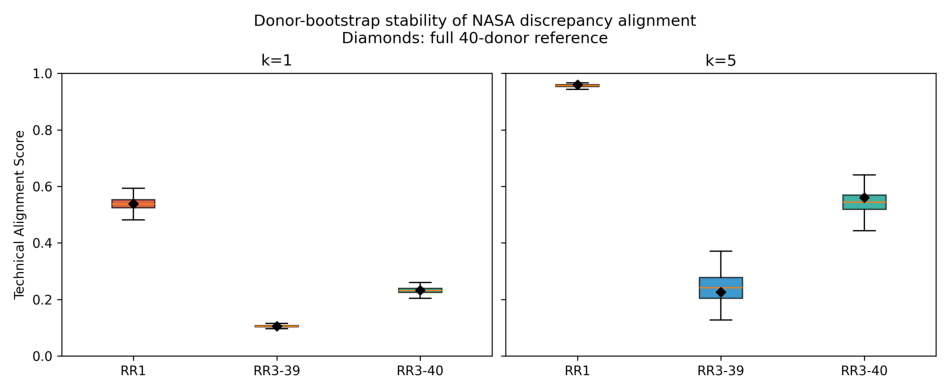

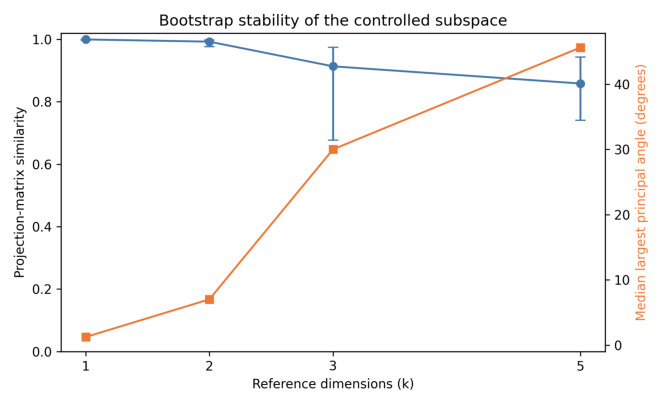

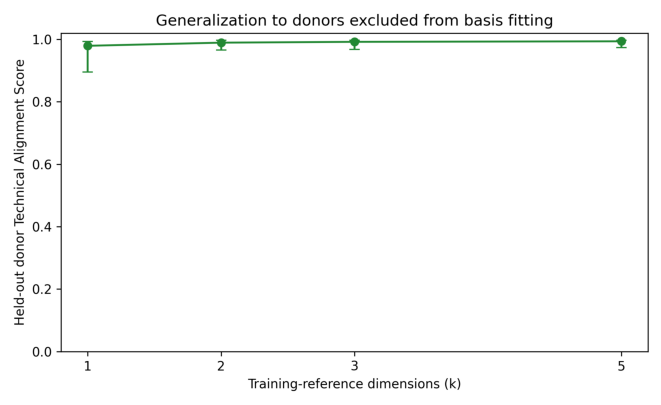

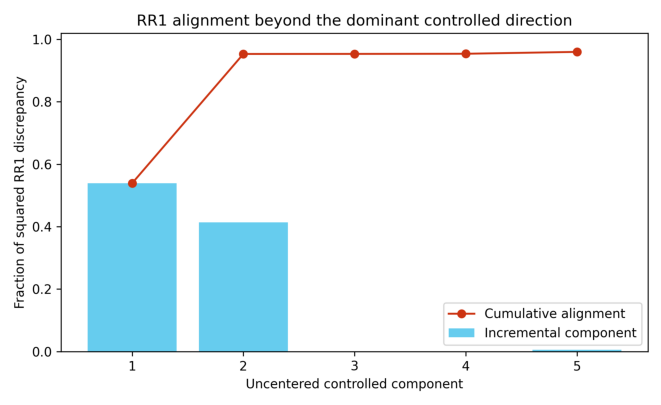

In [22]:
for name in ['figure_a_bootstrap_alignment.png','figure_b_subspace_stability.png','figure_c_heldout_donor_alignment.png','figure_d_rr1_cumulative_alignment.png']:
    img=plt.imread(robust_dir/name);plt.figure(figsize=(12,5));plt.imshow(img);plt.axis('off');plt.show()

### Secondary components and final robustness interpretation

PC1 is exceptionally stable: median bootstrap projection similarity is **0.9995**, with a median principal angle of **1.24°**. PC1–2 is also stable (median projection similarity **0.9925**; largest angle **7.01°**). The complete PC1–5 span is only moderately stable: median projection similarity is **0.8584**, and its largest principal angle is **45.60°** (95% interval 24.13°–85.76°).

Despite instability in weaker dimensions, the NASA profiler scores are stable. RR1 PC1–5 has bootstrap median **0.9566**, mean **0.9557**, SD **0.0054**, and 95% interval **0.9430–0.9637**, close to the full-reference value 0.9597. The ordering RR1 > RR3-40 > RR3-39 holds in 100% of bootstraps at every tested k.

The increase in RR1 is specifically dominated by two stable dimensions: PC1 contributes **0.5390** and PC2 contributes **0.4141**; PCs 3–5 together contribute only about **0.0066** in the full reference. Thus, the high PC1–5 score is reproducible because RR1 aligns strongly with the stable PC1–2 core—not because each of PC3–5 is individually reproducible.

The learned reference generalizes strongly within this controlled experiment. Across repeated 32/8 splits, held-out donor median alignment is **0.9792** for k=1 and **0.9936** for k=5; leave-one-donor-out values are nearly identical. This supports the Technical Alignment Score as a reproducible diagnostic of similarity to **this T-cell PolyA→Ribo transformation**. It does not establish a universal tissue-independent technical direction, causal attribution, purified biology, or successful batch correction.

## 11. BridgeRNA Technical Confounding Profiler

### Response context

**Biological system:** mouse liver  
**Perturbation:** spaceflight  
**Response:** Flight minus Ground Control  
**Comparison:** original measurement versus technical remeasurement

- **RR1:** OSD-48 versus OSD-168. PolyA, single-end 50-bp HiSeq 3000 sequencing transitions to ribodepletion, paired-end 150-bp HiSeq 4000 sequencing without ERCC; both were sequenced at UC Davis.
- **RR3-39 / RR3-40:** 39- and 40-day OSD-137 responses versus OSD-168 ERCC remeasurements. Both sides are ribodepleted, paired-end 150-bp HiSeq 4000 data from UC Davis.

The profiler keeps four questions separate: **Response Reproducibility** asks whether the response reproduced; **Technical Alignment Score** asks whether a discrepancy resembles the controlled transformation; **Biological Overlap** asks whether technical-associated structure intersects response geometry; and **Biological Impact** asks what molecular programs/features changed. They are not collapsed into one score.

$R=\cos(\Delta z_A,\Delta z_B)$ and $T=\|P_{PC1:2}\delta\|^2/\|\delta\|^2$, where $\delta=\Delta z_A-\Delta z_B$. PC1–2 is the operational reference learned from controlled same-RNA T-cell PolyA/Ribo pairs. Its cross-tissue universality has not been established. Category labels are descriptive, not inferential thresholds.

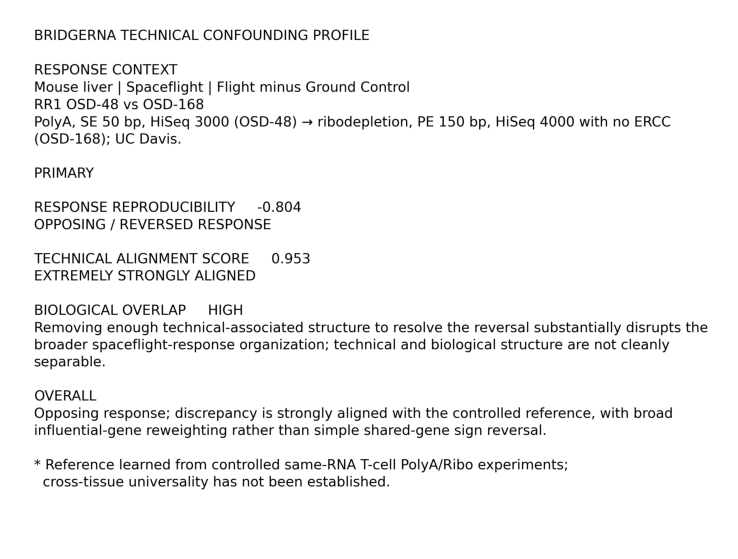

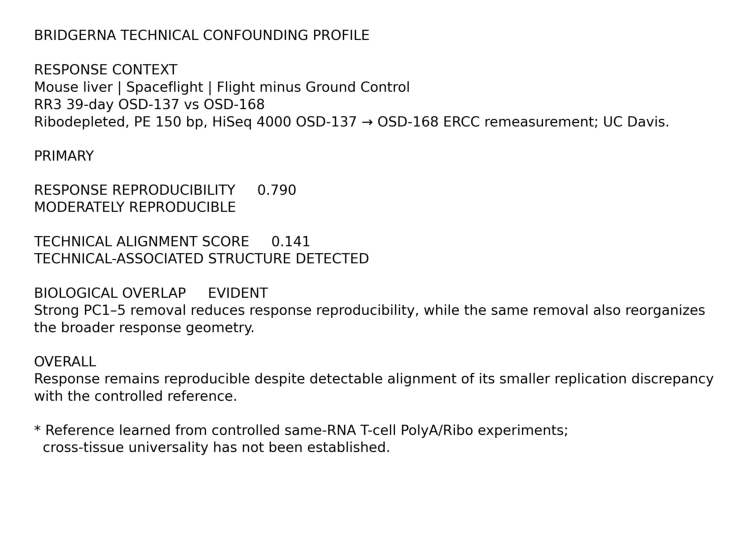

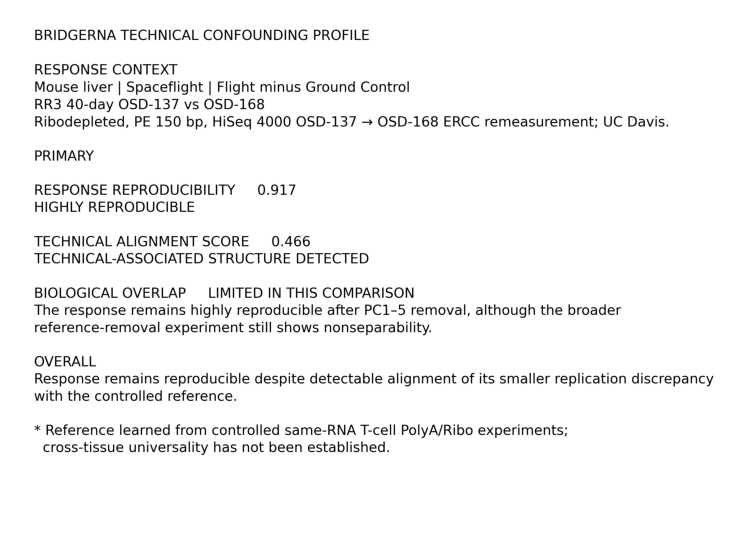

In [23]:
profiler_dir=RESULTS/'task4_confounding_profiler'
profiler=read_csv(profiler_dir/'profiler_summary.csv')
for name in ['rr1_profile.png','rr3_39_profile.png','rr3_40_profile.png']:
    img=plt.imread(profiler_dir/'figures'/name)
    plt.figure(figsize=(10,7));plt.imshow(img);plt.axis('off');plt.show()

### Technical Sensitivity Map

Dashed lines at `T=0.5` and `R=0` are visual guides only. RR3-40 is the key counterexample to treating technical alignment as automatic biological invalidation: technical-associated structure is detectable in its discrepancy while the primary FLT−GC response remains highly reproducible.

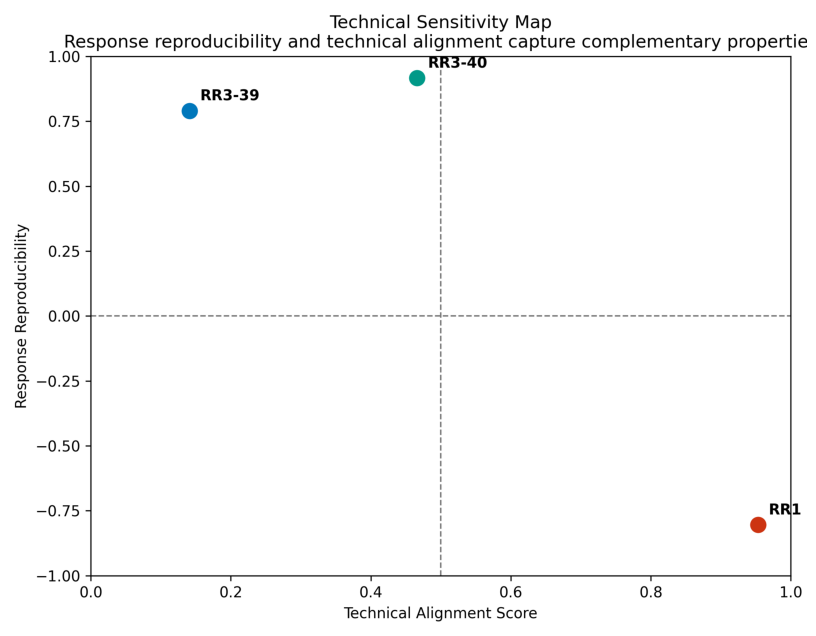

Comparison,Response Reproducibility,Response Category,Technical Alignment PC1-2,Biological Overlap,Biological Overlap Evidence
RR1,-0.804,Opposing / reversed response,0.953,HIGH,Removing enough technical-associated structure to resolve the reversal substantially disrupts the broader spaceflight-response organization; technical and biological structure are not cleanly separable.
RR3-39,0.790,Moderately reproducible,0.141,EVIDENT,"Strong PC1–5 removal reduces response reproducibility, while the same removal also reorganizes the broader response geometry."
RR3-40,0.917,Highly reproducible,0.466,LIMITED IN THIS COMPARISON,"The response remains highly reproducible after PC1–5 removal, although the broader reference-removal experiment still shows nonseparability."


In [24]:
img=plt.imread(profiler_dir/'technical_sensitivity_map.png')
plt.figure(figsize=(11,8));plt.imshow(img);plt.axis('off');plt.show()
primary=['Comparison','Response Reproducibility','Response Category','Technical Alignment PC1-2','Biological Overlap','Biological Overlap Evidence']
display(profiler[primary].style.format({'Response Reproducibility':'{:.3f}','Technical Alignment PC1-2':'{:.3f}'}).hide(axis='index'))

<details><summary><b>Technical Alignment Evidence — why trust T?</b></summary>

Bootstrap uncertainty asks whether donor resampling yields the same reference. Random-subspace calibration asks whether alignment exceeds chance geometry. Held-out-donor alignment asks whether a basis learned from some controlled donors captures the transformation in unseen T-cell donors.

PC1 has projection similarity 0.9995 and median principal angle 1.24°. PC1–2 has projection similarity 0.9925 and largest angle 7.01°. Repeated 32/8 held-out-donor median PC1–2 alignment is 0.9893. Full PC1–5 is only moderately stable and is not the operational profiler reference.
</details>

In [25]:
evidence=['Comparison','Technical Alignment PC1-2','PC1 Contribution','PC2 Contribution','Bootstrap Median','Bootstrap 95% Low','Bootstrap 95% High','Random-Subspace Percentile','Random-Subspace P']
display(profiler[evidence].style.format(precision=4).hide(axis='index'))

Comparison,Technical Alignment PC1-2,PC1 Contribution,PC2 Contribution,Bootstrap Median,Bootstrap 95% Low,Bootstrap 95% High,Random-Subspace Percentile,Random-Subspace P
RR1,0.9531,0.5390,0.4141,0.9476,0.9250,0.9577,1.0000,0.0010
RR3-39,0.1410,0.1057,0.0353,0.1400,0.1221,0.1600,1.0000,0.0010
RR3-40,0.4663,0.2323,0.2339,0.4643,0.4310,0.4992,1.0000,0.0010


<details><summary><b>Biological Overlap evidence</b></summary>

At PC1 removal, RR1 changes from −0.804 to −0.699 while broader response-matrix preservation is 0.988 and mode ARI remains 1.0. At PC1–5 removal, RR1 becomes +0.195, but matrix preservation falls to 0.559 and mode ARI to 0.116. Removing enough technical-associated structure to resolve RR1 therefore reorganizes broader spaceflight-response geometry. This identifies neither pure technical dimensions nor a pure biological residual.
</details>

In [26]:
overlap=read_csv(RESULTS/'task4_simple_correction_comparison/svd_correction_curve.csv')
display(overlap.query("method in ['none','svd_pc1_1','svd_pc1_5']")[['method','RR1','RR3-39','RR3-40','response_matrix_preservation','mode_ARI']].style.format(precision=3).hide(axis='index'))

method,RR1,RR3-39,RR3-40,response_matrix_preservation,mode_ARI
none,-0.804,0.790,0.917,1.000,1.000
svd_pc1_1,-0.699,0.719,0.880,0.988,1.000
svd_pc1_5,0.195,0.497,0.894,0.559,0.116


<details><summary><b>Biological Impact</b></summary>

Gene attribution measures which input genes BridgeRNA relied upon most strongly for the response. RR1's low signed attribution concordance means its gene-level basis was substantially reweighted. Because 96.2% of shared influential genes retain direction, this is not simple reversal of the same genes.

Existing enrichment implicates lipid metabolism, bile secretion, fatty-acid/peroxisomal metabolism, and small-molecule catabolism. These are biological programs implicated in the technically sensitive latent response—not pathways labeled as technical artifacts.
</details>

In [27]:
impact=['Comparison','Attribution Spearman','Top100 Shared','Shared Top100 Sign Agreement','Measurement-Specific Top100 Union','Existing Pathway Summary']
display(profiler[impact].style.format({'Attribution Spearman':'{:.3f}','Shared Top100 Sign Agreement':'{:.1%}'}).hide(axis='index'))

Comparison,Attribution Spearman,Top100 Shared,Shared Top100 Sign Agreement,Measurement-Specific Top100 Union,Existing Pathway Summary
RR1,0.194,53,96.2%,94,"Shared same-sign genes: small-molecule catabolism, cholesterol and related hepatic metabolism."
RR3-39,0.601,71,98.6%,58,"Reproducible genes: hepatic small-molecule, organic-acid, lipid and broader metabolic programs."
RR3-40,0.597,76,100.0%,48,"Reproducible genes: hepatic small-molecule, organic-acid, lipid and broader metabolic programs."


### Contextual gene-embedding feasibility

No cached per-sample `15,165 × 512` contextual gene-embedding tensors were found for the RR1/RR3 Task 3 samples. Available contextual-gene artifacts belong to the separate exercise-response benchmark and cannot answer this remeasurement question. Under the no-recomputation constraint, this exploratory analysis was not run. IG asks which genes influence a sample-level response; contextual embeddings would instead ask which genes' learned contexts change across remeasurement.

### Concise comparison and interpretation

1. **Expected behavior is reproduced.** RR1 is opposing (`R = −0.804`) and strongly aligned with PC1–2 (`T = 0.953`); RR3-39 is moderately reproducible (`R = 0.790`) with lower alignment (`T = 0.141`); RR3-40 is highly reproducible (`R = 0.917`) despite appreciable alignment (`T = 0.466`).
2. **R and T are distinct.** RR3-40 demonstrates that technical-associated structure can be detectable in the comparatively small discrepancy while the primary FLT−GC response remains reproducible.
3. **RR1 is unusually aligned.** Its score is above all 1,000 random two-dimensional subspaces (`p = 0.001`) and stable across donor bootstraps (median 0.948; 95% interval 0.925–0.958).
4. **Biological overlap matters.** Stronger removal resolves RR1 only while disrupting broader response organization; technical-associated and biological structure are not cleanly separable.
5. **Attribution adds impact context.** RR1 shows gene reweighting within hepatic metabolic programs, while RR3 has greater attribution concordance and Top-100 overlap.
6. **The assumption remains explicit.** The reference is stable within controlled T cells, but its cross-tissue universality is unknown.

**RR1 overall:** The mouse-liver spaceflight response is technically unstable. Its discrepancy strongly resembles the independently characterized PolyA/Ribo transformation, but associated latent dimensions overlap biological-response structure and cannot be cleanly removed without changing broader organization. This is diagnostic alignment, not causal attribution or batch correction.

## 12. Final benchmark summary

In [28]:
if not summary.empty:
    final = summary.rename(columns={'representation':'Representation','auroc':'PolyA/Ribo AUROC','pair_cosine':'Pair cosine','pair_r1':'Pair R@1'})
    if not task3.empty:
        challenge = task3.pivot(index='representation',columns='comparison',values='cosine').reset_index().rename(columns={'representation':'Representation'})
        final = final.merge(challenge, on='Representation', how='left')
    final = final.rename(columns={'biology_metric_value':'Biology metric (source-ID MRR)'})
    keep = [c for c in ['Representation','PolyA/Ribo AUROC','Pair cosine','Pair R@1','Biology metric (source-ID MRR)','macro_f1','RR1','RR3-39','RR3-40'] if c in final]
    display(final[keep].style.format(precision=3,na_rep='—'))

,Representation,PolyA/Ribo AUROC,Pair cosine,Pair R@1,Biology metric (source-ID MRR),macro_f1,RR1,RR3-39,RR3-40
0,Bridge,0.000,0.882,0.750,0.875,0.200,-0.804,0.790,0.917
1,Linear baseline,0.500,0.883,0.750,0.875,0.333,-0.709,0.724,0.881
2,FE,0.000,0.786,0.500,0.750,0.333,-0.994,0.998,0.995
3,RE,0.000,0.165,0.500,0.750,0.200,-0.902,0.580,0.999
4,FE without_pair,0.000,0.838,0.500,0.750,0.333,—,—,—
5,FE without_adversarial,0.078,0.996,0.500,0.750,0.200,—,—,—
6,FE shuffled_labels,0.000,1.000,0.500,0.750,0.000,—,—,—
7,FE shuffled_pairs,0.000,0.986,0.500,0.750,0.333,—,—,—


## 13. Conservative interpretation

The completed evidence should answer whether original Bridge encodes library information, whether displacement generalizes, whether FE reduces it without erasing biology, whether RE isolates it, whether the decomposition generalizes, and whether RR1 improves without damaging RR3.

Until several independent authoritative same-RNA studies are available, generalization and causal attribution remain provisional. The current external test contains only two biological source RNAs, so effect sizes and failures matter more than nominal significance.

In [29]:
if not summary.empty and not task3.empty:
    s = summary.set_index('representation')
    t = task3.pivot(index='representation',columns='comparison',values='cosine')
    print(f"Held-out Bridge AUROC: {s.loc['Bridge','auroc']:.3f}; FE AUROC: {s.loc['FE','auroc']:.3f}; RE AUROC: {s.loc['RE','auroc']:.3f}")
    print(f"Pair cosine Bridge→FE: {s.loc['Bridge','pair_cosine']:.3f} → {s.loc['FE','pair_cosine']:.3f}")
    print(f"Pair R@1 Bridge→FE: {s.loc['Bridge','pair_r1']:.3f} → {s.loc['FE','pair_r1']:.3f}")
    print(f"RR1 cosine Bridge→FE: {t.loc['Bridge','RR1']:.3f} → {t.loc['FE','RR1']:.3f}")
    print('Conclusion: this exploratory FE/RE fit does not meet the predefined success criteria. It neither improves held-out pair correspondence nor remedies RR1. The result cannot specifically implicate PolyA/Ribo; the RR1 reversal remains attributable to a broader protocol transition.')

Held-out Bridge AUROC: 0.000; FE AUROC: 0.000; RE AUROC: 0.000
Pair cosine Bridge→FE: 0.882 → 0.786
Pair R@1 Bridge→FE: 0.750 → 0.500
RR1 cosine Bridge→FE: -0.804 → -0.994
Conclusion: this exploratory FE/RE fit does not meet the predefined success criteria. It neither improves held-out pair correspondence nor remedies RR1. The result cannot specifically implicate PolyA/Ribo; the RR1 reversal remains attributable to a broader protocol transition.
